In [1]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from ultralytics import SAM
import os
from pathlib import Path

In [2]:
# Set device
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: mps


In [3]:
# Initialize YOLO World model
yolo_model = YOLO("yolov8s-world.pt")

# Set custom classes for YOLO World
yolo_model.set_classes(["screw", "defect", "anomaly"])


100%|██████████| 25.9M/25.9M [00:00<00:00, 28.6MB/s]


In [4]:
# Initialize SAM model for segmentation
sam_model = SAM("mobile_sam.pt")


In [5]:
# Test data path
test_image_dir = "/Users/theo.moreau/Documents/futur/datasets/mvtec_anomaly_detection/screw/test"

# Load test image
image_path = os.path.join(test_image_dir, "good", os.listdir(os.path.join(test_image_dir, "good"))[0])
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print(f"Loaded image: {image_path}")
print(f"Image shape: {image_rgb.shape}")


Loaded image: /Users/theo.moreau/Documents/futur/datasets/mvtec_anomaly_detection/screw/test/good/002.png
Image shape: (1024, 1024, 3)



0: 640x640 (no detections), 302.7ms
Speed: 3.7ms preprocess, 302.7ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
YOLO detected 0 objects


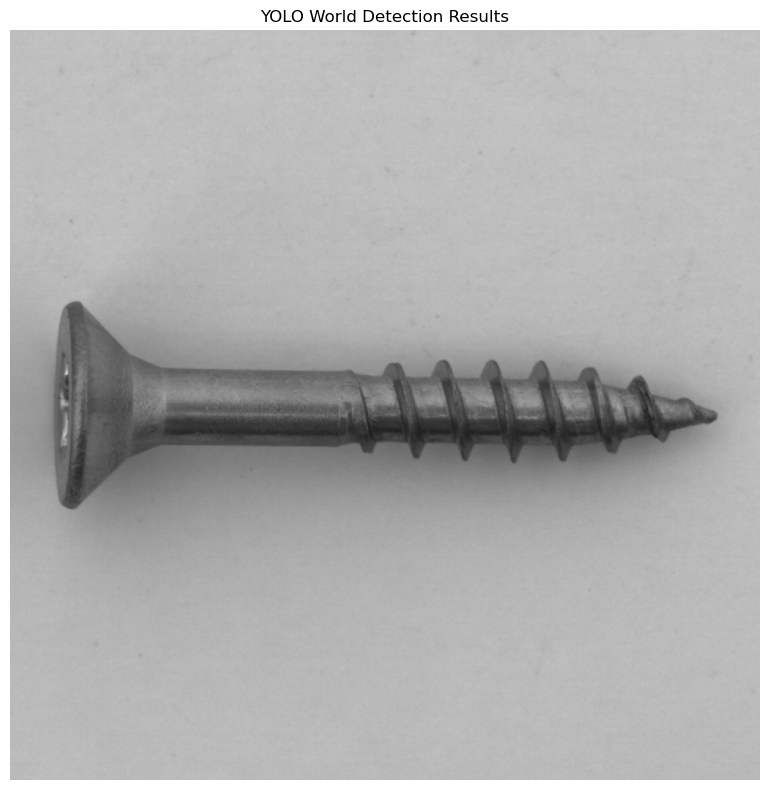

In [6]:
# Run YOLO World detection
yolo_results = yolo_model(image_rgb)

# Extract bounding boxes
boxes = yolo_results[0].boxes.xyxy.cpu().numpy() if yolo_results[0].boxes is not None else []

print(f"YOLO detected {len(boxes)} objects")

# Visualize YOLO results
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(image_rgb)
ax.set_title("YOLO World Detection Results")

for box in boxes:
    x1, y1, x2, y2 = box
    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red', linewidth=2)
    ax.add_patch(rect)

ax.axis('off')
plt.tight_layout()
plt.show()


In [7]:
# Use YOLO bounding boxes as prompts for SAM
if len(boxes) > 0:
    # Run SAM with box prompts
    sam_results = sam_model(image_rgb, bboxes=boxes)
    
    # Visualize SAM segmentation results
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Original image with YOLO boxes
    axes[0].imshow(image_rgb)
    axes[0].set_title("YOLO Detection")
    for box in boxes:
        x1, y1, x2, y2 = box
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red', linewidth=2)
        axes[0].add_patch(rect)
    axes[0].axis('off')
    
    # SAM segmentation results
    axes[1].imshow(image_rgb)
    axes[1].set_title("SAM Segmentation from YOLO Boxes")
    
    if sam_results[0].masks is not None:
        masks = sam_results[0].masks.data.cpu().numpy()
        for i, mask in enumerate(masks):
            colored_mask = np.zeros((*mask.shape, 3))
            color = np.random.rand(3)
            colored_mask[mask > 0] = color
            axes[1].imshow(colored_mask, alpha=0.5)
    
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No objects detected by YOLO World")


No objects detected by YOLO World
